In [1]:
from pathlib import Path
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from destripe import destripe
from destripe.adaptive import estimate_adaptive_params
from destripe.preprocess import prepare_solver_gray

In [2]:
path = ROOT / 'asset' / 'sample.jpeg'
image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
if image is None:
    raise ValueError(f'Could not read {path}')
image.shape, image.dtype

((321, 517), dtype('uint8'))

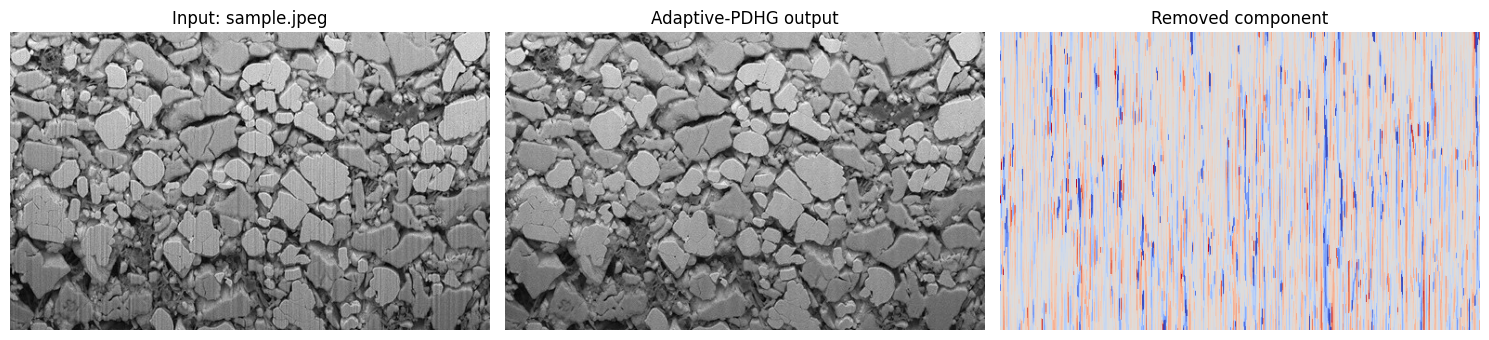

{'directions': (0,),
 'mu1': 0.25,
 'mu2': 0.01,
 'confidence': 0.23451999430676218,
 'correction_rms_8bit': 7.593216395586935}

In [3]:
process_size = 512
clean = destripe(image, process_size=process_size)
normalized = image.astype(np.float64) / 255.0
solver_gray = prepare_solver_gray(gray=normalized, process_size=process_size)
params = estimate_adaptive_params(solver_gray)
correction = image.astype(np.float64) - clean.astype(np.float64)
scale = max(float(np.percentile(np.abs(correction), 99)), 1e-6)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Input: sample.jpeg')
axes[1].imshow(clean, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Adaptive-PDHG output')
axes[2].imshow(correction, cmap='coolwarm', vmin=-scale, vmax=scale)
axes[2].set_title('Removed component')
for axis in axes:
    axis.axis('off')
plt.tight_layout()
plt.show()

{
    'directions': params.directions,
    'mu1': params.mu1,
    'mu2': params.mu2,
    'confidence': params.confidence,
    'correction_rms_8bit': float(np.sqrt(np.mean(correction**2))),
}